Name = sharvil Vichare
Roll no = B39
PRN = 2324000814


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
img = cv.imread('/content/download.jfif')

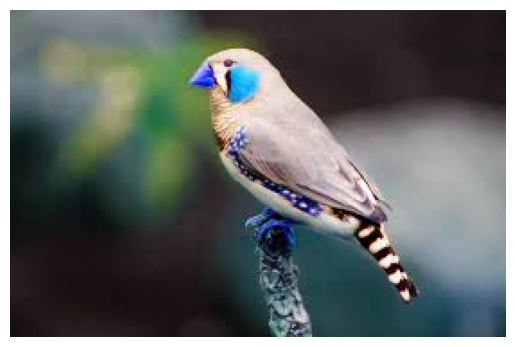

In [ ]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
img_grayscale = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [ ]:
hist = [0] * 256
rows, cols = img_grayscale.shape
for i in range(rows):
    for j in range(cols):
        pixel = img_grayscale[i][j]
        hist[pixel] += 1

In [ ]:
total_pixels = rows * cols
hist_norm = [h / total_pixels for h in hist]

In [ ]:
cdf = [0] * 256
cdf[0] = hist_norm[0]
# The plotting will be done in a separate cell after the full CDF is calculated.

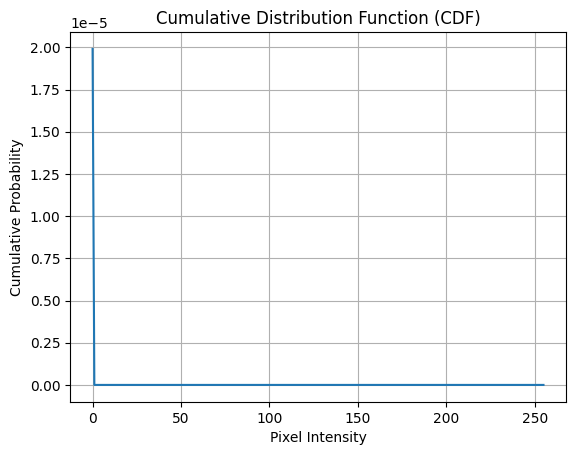

In [ ]:
plt.plot(cdf)
plt.title('Cumulative Distribution Function (CDF)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.show()

In [ ]:
for i in range(1, 256):
    cdf[i] = cdf[i-1] + hist_norm[i]

In [ ]:
new_values = [round(255 * cdf[i]) for i in range(256)]

In [ ]:
equalized_img = np.zeros((rows, cols), dtype=np.uint8)
for i in range(rows):
    for j in range(cols):
        equalized_img[i][j] = new_values[img_grayscale[i][j]]


(np.float64(-0.5), np.float64(275.5), np.float64(181.5), np.float64(-0.5))

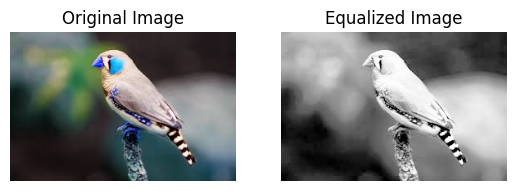

In [ ]:
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Equalized Image")
plt.imshow(equalized_img, cmap='gray')
plt.axis('off')